In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

Fashion-MNIST uses values of 0 and 255 to represent binary states. This is flattened to {0, 1}.

In [5]:
X, y = fetch_openml("Fashion-MNIST", version=1, as_frame=False, return_X_y=True)
X = X / 255.0
y = y.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=10000, random_state=42, shuffle=True)

Set up a MLPClassifier with 64 neurons, the ReLU acticvation function, a batch size of 256, and the default learning rate.


In [6]:
mlp_factory = lambda: MLPClassifier(hidden_layer_sizes=(64, ), activation='relu', solver='sgd', batch_size=256, random_state=42, learning_rate_init=0.001, early_stopping=True)
n_tr_values = [100, 500, 1000, 10000]
train_errors = []
test_errors = []


def train_model(X_tr, y_tr, X_te, y_te, n_tr_values, model_factory):
    for n in n_tr_values:
        X_tr_fit = model_factory().fit(X_tr[:n], y_tr[:n])
        train_errors.append(1 - accuracy_score(y_tr, X_tr_fit.predict(X_tr)))
        X_te_fit = model_factory().fit(X_te[:n], y_te[:n])
        test_errors.append(1 - accuracy_score(y_te, X_te_fit.predict(X_te)))

    return np.asarray(train_errors), np.asarray(test_errors)
 
tr, te = train_model(X_tr, y_tr, X_te, y_te, n_tr_values, mlp_factory)
print(f'Training errors: {tr}, testing errors: {te}')

/home/136petrified/py-sandbox/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


/home/136petrified/py-sandbox/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Training errors: [0.8132     0.70805    0.31871667 0.18561667], testing errors: [0.7505 0.4165 0.3552 0.1826]


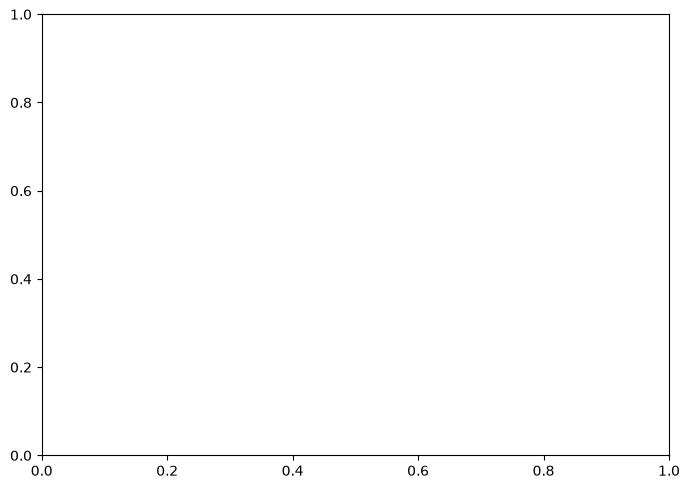

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

plt.tight_layout()